In [725]:
import matplotlib.pyplot as plt
import pandas as pd
import math, numpy as np
import re
import seaborn as sns

In [726]:
time_cache = '../data/outs/0328/all_time_cache.csv'

try:
    df_tcache = pd.read_csv(time_cache, sep=' ')
    print("Dados lidos com sucesso!")

except FileNotFoundError:
    print(f"Erro: Arquivo não encontrado!")

Dados lidos com sucesso!


In [727]:
df_tcache.dtypes

nome           object
n               int64
m               int64
c               int64
insert          int64
extractMin      int64
dk              int64
bkmp            int64
fila           object
cpu_time        int64
wall_time       int64
l1_ac           int64
l1_miss         int64
llc_ac          int64
llc_miss        int64
cycles          int64
inst            int64
dtlb            int64
page_faults     int64
branch_inst     int64
branch_miss     int64
dtype: object

In [728]:
# selecionar todos que não são MEM

df_tcache = df_tcache[~df_tcache["nome"].str.startswith("MEM")]

## Tabela Geral dos EUA

In [729]:
df_usa = df_tcache[df_tcache["nome"] == "USA"]
df_usa.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
1540,USA,23947347,58333344,368855,25662938,25662938,0,21683099,1LVBQ,6588,...,12874532940,331165557,86572369,27644196,15242577240,26623182702,21178627,745,4931860144,47357731
1541,USA,23947347,58333344,368855,25664333,25664333,0,28182270,1LVBQ,6496,...,12974300959,316842302,77048105,25885320,15013903101,26760062935,17226050,0,4937735913,48925743
1542,USA,23947347,58333344,368855,25660418,25660418,0,25075013,1LVBQ,6564,...,12933699339,325811836,83159049,27063810,15172297035,26721211017,19637836,0,4940759050,47967742
1543,USA,23947347,58333344,368855,25665358,25665358,0,27288232,1LVBQ,6564,...,12949809287,311233846,73715655,25014561,15129195360,26715846906,15924201,0,4924961587,49551649
1544,USA,23947347,58333344,368855,25667417,25667417,0,12754745,1LVBQ,6772,...,12706633560,335233836,89784485,26639427,15708127158,26360102460,22527438,216,4902555435,45725642


In [730]:
df_usa = df_usa.groupby("fila").mean(numeric_only=True)
df_usa

,n,m,c,insert,extractMin,dk,bkmp,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
fila,,,,,,,,,,,,,,,,,,,
1LVBQ,23947347.0,58333344.0,368855.0,25662276.6,25662276.6,0.0,22823173.6,6653.5,6654.6,1.287974e+10,322859900.1,81341942.0,26319310.3,1.540779e+10,2.661595e+10,19034062.3,97.6,4.924174e+09,48128092.0
1LVBQDK,23947347.0,58333344.0,368855.0,25663885.6,23947347.0,1716538.6,25299666.2,5836.1,5837.1,1.134632e+10,372881008.3,78184367.3,21664227.4,1.358258e+10,2.219531e+10,20394124.5,0.0,3.546879e+09,58270372.8
2LVBQ,23947347.0,58333344.0,368855.0,25664646.9,25664646.9,0.0,40930355.1,6794.9,6795.9,1.712303e+10,286307397.9,57232240.5,18219344.5,1.535322e+10,3.504791e+10,14999209.8,0.0,6.611895e+09,48457797.9
2LVBQDK,23947347.0,58333344.0,368855.0,25664980.4,23947347.0,1717633.4,43504881.6,6310.4,6311.2,1.402046e+10,400178171.1,69410282.8,19566258.3,1.456681e+10,2.677379e+10,19369470.2,0.8,3.950129e+09,59855392.5
3LVBQ,23947347.0,58333344.0,368855.0,31053789.6,31053789.6,0.0,4675057.1,7817.1,7818.6,2.250006e+10,253423373.4,51972729.3,15856711.9,1.726330e+10,4.550391e+10,12241816.7,0.0,7.874974e+09,47772734.1
3LVBQDK,23947347.0,58333344.0,368855.0,31049919.2,27974868.4,3075050.8,4370906.1,7337.2,7338.4,1.856778e+10,415090251.3,74776058.1,19956437.7,1.665107e+10,3.521294e+10,20225336.0,1.6,4.790884e+09,53586896.0
4LVBQ,23947347.0,58333344.0,368855.0,35990404.1,35990404.1,0.0,2137847.3,9066.0,9067.3,2.681625e+10,278883861.7,59689755.6,17369266.2,2.000565e+10,5.398084e+10,14300845.4,0.0,9.252949e+09,51419314.2
4LVBQDK,23947347.0,58333344.0,368855.0,35974817.2,32200516.0,3774301.2,2029553.2,8309.3,8310.2,2.216661e+10,463787149.2,82948455.6,20699807.9,1.876441e+10,4.177588e+10,21910868.4,0.0,5.626250e+09,55666877.3
5LVBQ,23947347.0,58333344.0,368855.0,26671372.7,26671372.7,0.0,3768459.4,7973.6,7974.6,2.325934e+10,227109205.9,53544190.6,17243609.4,1.771135e+10,4.689231e+10,13262232.1,0.0,7.872554e+09,43673762.7


In [731]:
df_usa = df_usa.copy()
df_usa.head()

df_usa["ipc"] = df_usa["inst"] / df_usa["cycles"]

colunas = [
    "cpu_time", "wall_time", "l1_ac", "l1_miss",
    "llc_ac", "llc_miss", "branch_inst", "branch_miss", "inst"
]

df_usa = df_usa[colunas]

In [732]:
df_usa.min()

cpu_time       5.836100e+03
wall_time      5.837100e+03
l1_ac          1.134632e+10
l1_miss        2.271092e+08
llc_ac         4.881429e+07
llc_miss       1.585671e+07
branch_inst    3.546879e+09
branch_miss    4.323415e+07
inst           2.219531e+10
dtype: float64

In [733]:
num = df_usa.select_dtypes(include="number").copy()
df_norm = num / num.min()

In [734]:
df_norm.style.highlight_min(axis=0, color="lightgreen").highlight_max(axis=0, color="salmon")

,cpu_time,wall_time,l1_ac,l1_miss,llc_ac,llc_miss,branch_inst,branch_miss,inst
fila,,,,,,,,,
1LVBQ,1.140059,1.140052,1.135148,1.421606,1.666355,1.659821,1.388312,1.113196,1.199170
1LVBQDK,1.000000,1.000000,1.000000,1.641858,1.601670,1.366250,1.000000,1.347786,1.000000
2LVBQ,1.164288,1.164260,1.509126,1.260660,1.172449,1.148999,1.864144,1.120822,1.579068
2LVBQDK,1.081270,1.081222,1.235684,1.762052,1.421926,1.233942,1.113692,1.384447,1.206281
3LVBQ,1.339439,1.339467,1.983028,1.115866,1.064703,1.000000,2.220254,1.104977,2.050158
3LVBQDK,1.257209,1.257200,1.636459,1.827712,1.531848,1.258548,1.350732,1.239458,1.586503
4LVBQ,1.553435,1.553391,2.363432,1.227973,1.222793,1.095389,2.608758,1.189322,2.432082
4LVBQDK,1.423776,1.423686,1.953640,2.042133,1.699266,1.305429,1.586254,1.287567,1.882194
5LVBQ,1.366255,1.366192,2.049946,1.000000,1.096896,1.087464,2.219572,1.010168,2.112712


In [735]:
latex = df_norm.to_latex(
    index=True,
    float_format="%.2f",
    longtable=False,
    escape=False
)

print(latex)

\begin{tabular}{lrrrrrrrrr}
\toprule
 & cpu_time & wall_time & l1_ac & l1_miss & llc_ac & llc_miss & branch_inst & branch_miss & inst \\
fila &  &  &  &  &  &  &  &  &  \\
\midrule
1LVBQ & 1.14 & 1.14 & 1.14 & 1.42 & 1.67 & 1.66 & 1.39 & 1.11 & 1.20 \\
1LVBQDK & 1.00 & 1.00 & 1.00 & 1.64 & 1.60 & 1.37 & 1.00 & 1.35 & 1.00 \\
2LVBQ & 1.16 & 1.16 & 1.51 & 1.26 & 1.17 & 1.15 & 1.86 & 1.12 & 1.58 \\
2LVBQDK & 1.08 & 1.08 & 1.24 & 1.76 & 1.42 & 1.23 & 1.11 & 1.38 & 1.21 \\
3LVBQ & 1.34 & 1.34 & 1.98 & 1.12 & 1.06 & 1.00 & 2.22 & 1.10 & 2.05 \\
3LVBQDK & 1.26 & 1.26 & 1.64 & 1.83 & 1.53 & 1.26 & 1.35 & 1.24 & 1.59 \\
4LVBQ & 1.55 & 1.55 & 2.36 & 1.23 & 1.22 & 1.10 & 2.61 & 1.19 & 2.43 \\
4LVBQDK & 1.42 & 1.42 & 1.95 & 2.04 & 1.70 & 1.31 & 1.59 & 1.29 & 1.88 \\
5LVBQ & 1.37 & 1.37 & 2.05 & 1.00 & 1.10 & 1.09 & 2.22 & 1.01 & 2.11 \\
5LVBQDK & 1.26 & 1.26 & 1.70 & 1.77 & 1.46 & 1.25 & 1.26 & 1.14 & 1.63 \\
6LVBQ & 1.38 & 1.38 & 2.08 & 1.01 & 1.12 & 1.10 & 2.23 & 1.00 & 2.14 \\
6LVBQDK & 1.28 & 

# Tempo de execução

In [736]:
df_tcache.head()

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,...,l1_ac,l1_miss,llc_ac,llc_miss,cycles,inst,dtlb,page_faults,branch_inst,branch_miss
0,NY,264346,733846,36946,298760,298760,0,875156,1LVBQ,68,...,187770154,2853295,327778,139940,174261675,411683338,14140,76,74111933,759040
1,NY,264346,733846,36946,298765,298765,0,793429,1LVBQ,67,...,186594232,2769832,307427,132797,166297298,400688261,14048,0,73090719,747622
2,NY,264346,733846,36946,299090,299090,0,1266493,1LVBQ,66,...,191153391,2831534,314002,119309,159632078,399958280,10717,0,72293451,729795
3,NY,264346,733846,36946,299174,299174,0,777084,1LVBQ,66,...,185284807,2742005,293170,120520,158564672,390385866,12719,0,72063345,738137
4,NY,264346,733846,36946,299348,299348,0,905321,1LVBQ,66,...,185927701,2767935,300679,126315,160760654,393607716,12412,0,71892564,739982


### Perguntas

#### Gerais
- Em média, quanto extractMin a mais são realizados em filas sem DK? (incluir DK)
- Quem realiza mais/menos instruções por instância?
- Quem tem mais cache miss (total e rate) por instância?
- Quem tem mais branch miss (total e rate) por instância?
- Dtlb e page faults tem alguma relevância?

#### Buckets
- Quantos buckets vazios cada estrutura avalia?
- Quantas operações de expansão são realizadas?
- Quantos updates cada estrutura realiza?
- Qual bucket tem mais/menos branch miss (total e rate) por instância?
- Quel bucket tem mais/menos cache miss (total e rate) por instância?


In [737]:
df_tcache['extra_extractMin'] = df_tcache['extractMin'] - df_tcache['n']
df_tcache['l1_rate'] = df_tcache['l1_miss'] / df_tcache['l1_ac']
df_tcache['llc_rate'] = df_tcache['llc_miss'] / df_tcache['llc_ac']
df_tcache['ipc'] = df_tcache['inst'] / df_tcache['cycles'] # quanto maior, melhor
df_tcache['dtlb_rate'] = df_tcache['dtlb'] / df_tcache['inst'] # melhor menor
df_tcache['pf_rate'] = df_tcache['page_faults'] / df_tcache['inst'] # melhor menor
df_tcache['bm_rate'] = df_tcache['branch_miss'] / df_tcache['branch_inst']

In [738]:
df_abs = (
    df_tcache.groupby(['nome','fila'], as_index=False)
    .agg(
        # Características e OPS
        n=('n', 'first'),
        m=('m', 'first'),
        c=('c', 'first'),
        extra_extracMin=('extra_extractMin', 'first'),
        dk =('dk', 'first'),
        bkmp=('bkmp','first'),
        #exp=('upd', 'first')

        # Processamento
        cpu_t_mean=('cpu_time', 'mean'),
        cpu_t_std =('cpu_time', 'std'),
        cpu_t_var =('cpu_time', 'var'),

        wall_t_mean=('wall_time', 'mean'),
        wall_t_std =('wall_time', 'std'),
        wall_t_var =('wall_time', 'var'),

        inst_mean=('inst', 'mean'),
        inst_std=('inst', 'std'),
        inst_var=('inst', 'var'),

        l1_mean = ('l1_miss', 'mean'),
        l1_std = ('l1_miss', 'std'),
        l1_var = ('l1_miss', 'var'),

        llc_mean = ('llc_miss', 'mean'),
        llc_std = ('llc_miss', 'std'),
        llc_var = ('llc_miss', 'var'),

        ipc_mean = ('ipc', 'mean'),
        ipc_std=('ipc', 'std'),
        ipc_var=('ipc', 'var'),

        dlb_mean = ('dtlb', 'mean'),
        dtlb_std=('dtlb', 'std'),
        dtlb_var=('dtlb', 'var'),

        pf_mean = ('page_faults', 'mean'),
        pf_std=('page_faults', 'std'),
        pf_var=('page_faults', 'var'),

        bm_mean = ('branch_miss', 'mean'),
        bm_std=('branch_miss', 'std'),
        bm_var=('branch_miss', 'var'),
        
    )
)
df_abs

,nome,fila,n,m,c,extra_extracMin,dk,bkmp,cpu_t_mean,cpu_t_std,...,ipc_var,dlb_mean,dtlb_std,dtlb_var,pf_mean,pf_std,pf_var,bm_mean,bm_std,bm_var
0,BAY,1LVBQ,321270,800172,94305,25614,0,2641802,85.0,1.247219,...,0.003113,21726.0,2.433249e+03,5.920700e+06,0.0,0.0,0.0,853112.6,17756.658026,3.152989e+08
1,BAY,1LVBQDK,321270,800172,94305,0,25455,2067426,60.0,0.816497,...,0.002547,14223.6,3.107862e+03,9.658803e+06,0.0,0.0,0.0,748941.0,13838.942301,1.915163e+08
2,BAY,2LVBQ,321270,800172,94305,25332,0,2443032,93.1,1.911951,...,0.001385,11747.8,2.376414e+03,5.647345e+06,0.0,0.0,0.0,713221.4,6062.194601,3.675020e+07
3,BAY,2LVBQDK,321270,800172,94305,0,25377,2424161,67.6,1.074968,...,0.000678,15094.7,2.516793e+03,6.334249e+06,0.0,0.0,0.0,772830.1,8874.964945,7.876500e+07
4,BAY,3LVBQ,321270,800172,94305,55215,0,190751,85.4,0.699206,...,0.000702,10442.9,2.242482e+03,5.028727e+06,0.0,0.0,0.0,711515.5,22092.628963,4.880843e+08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,W,5LVBQDK,6262104,15248146,368855,148011,546878,2044548,1805.4,31.503792,...,0.002828,2493415.8,6.313493e+05,3.986019e+11,0.0,0.0,0.0,15362465.3,535280.579376,2.865253e+11
164,W,6LVBQ,6262104,15248146,368855,711230,0,2198325,2050.1,22.805701,...,0.002493,1534608.2,3.126123e+05,9.772643e+10,0.0,0.0,0.0,12704997.3,271545.551607,7.373699e+10
165,W,6LVBQDK,6262104,15248146,368855,151382,546446,2733524,1831.5,44.540244,...,0.005174,2755195.1,8.108092e+05,6.574115e+11,0.0,0.0,0.0,15098950.1,629770.388290,3.966107e+11
166,W,BINH,6262104,15248146,368855,453477,0,0,2772.0,91.971010,...,0.001195,1561327.5,6.468666e+05,4.184364e+11,0.0,0.0,0.0,36880966.5,940349.264037,8.842567e+11


In [739]:
df_rates = (
    df_tcache.groupby(['nome', 'fila'], as_index=False)
      .agg(
           
           # Características e OPS
           n=('n', 'first'),
           m=('m', 'first'),
           c=('c', 'first'),
           extra_extracMin=('extra_extractMin', 'first'),
           dk =('dk', 'first'),
           bkmp=('bkmp','first'),
           #exp=('upd', 'first')

           # Processamento

           cpu_t_mean=('cpu_time', 'mean'),
           cpu_t_std =('cpu_time', 'std'),
           cpu_t_var =('cpu_time', 'var'),

           wall_t_mean=('wall_time', 'mean'),
           wall_t_std =('wall_time', 'std'),
           wall_t_var =('wall_time', 'var'),

           l1_mean = ('l1_rate', 'mean'),
           l1_std = ('l1_rate', 'std'),
           l1_var = ('l1_rate', 'var'),

           llc_mean = ('llc_rate', 'mean'),
           llc_std = ('llc_rate', 'std'),
           llc_var = ('llc_rate', 'var'),

           ipc_mean = ('ipc', 'mean'),
           ipc_std=('ipc', 'std'),
           ipc_var=('ipc', 'var'),

           dlb_mean = ('dtlb_rate', 'mean'),
           dtlb_std=('dtlb_rate', 'std'),
           dtlb_var=('dtlb_rate', 'var'),

           pf_mean = ('pf_rate', 'mean'),
           pf_std=('pf_rate', 'std'),
           pf_var=('pf_rate', 'var'),

           bm_mean = ('bm_rate', 'mean'),
           bm_std=('bm_rate', 'std'),
           bm_var=('bm_rate', 'var'),
      )
)
df_rates

,nome,fila,n,m,c,extra_extracMin,dk,bkmp,cpu_t_mean,cpu_t_std,...,ipc_var,dlb_mean,dtlb_std,dtlb_var,pf_mean,pf_std,pf_var,bm_mean,bm_std,bm_var
0,BAY,1LVBQ,321270,800172,94305,25614,0,2641802,85.0,1.247219,...,0.003113,0.000042,0.000005,2.458678e-11,0.0,0.0,0.0,0.009307,0.000201,4.040804e-08
1,BAY,1LVBQDK,321270,800172,94305,0,25455,2067426,60.0,0.816497,...,0.002547,0.000041,0.000009,8.230445e-11,0.0,0.0,0.0,0.014445,0.000393,1.541442e-07
2,BAY,2LVBQ,321270,800172,94305,25332,0,2443032,93.1,1.911951,...,0.001385,0.000018,0.000004,1.814188e-11,0.0,0.0,0.0,0.005631,0.000160,2.563424e-08
3,BAY,2LVBQDK,321270,800172,94305,0,25377,2424161,67.6,1.074968,...,0.000678,0.000038,0.000007,4.296433e-11,0.0,0.0,0.0,0.013668,0.000113,1.286079e-08
4,BAY,3LVBQ,321270,800172,94305,55215,0,190751,85.4,0.699206,...,0.000702,0.000018,0.000004,1.446477e-11,0.0,0.0,0.0,0.007059,0.000217,4.690166e-08
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,W,5LVBQDK,6262104,15248146,368855,148011,546878,2044548,1805.4,31.503792,...,0.002828,0.000261,0.000066,4.382807e-09,0.0,0.0,0.0,0.013074,0.000449,2.017869e-07
164,W,6LVBQ,6262104,15248146,368855,711230,0,2198325,2050.1,22.805701,...,0.002493,0.000121,0.000025,6.255677e-10,0.0,0.0,0.0,0.006000,0.000109,1.195564e-08
165,W,6LVBQDK,6262104,15248146,368855,151382,546446,2733524,1831.5,44.540244,...,0.005174,0.000284,0.000084,7.060571e-09,0.0,0.0,0.0,0.012708,0.000522,2.725003e-07
166,W,BINH,6262104,15248146,368855,453477,0,0,2772.0,91.971010,...,0.001195,0.000095,0.000037,1.357404e-09,0.0,0.0,0.0,0.013804,0.000083,6.825353e-09


In [740]:
df_time = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time', 'wall_time']
].copy()
df_time

,nome,n,c,fila,cpu_time,wall_time
0,NY,264346,36946,1LVBQ,68,68
1,NY,264346,36946,1LVBQ,67,67
2,NY,264346,36946,1LVBQ,66,66
3,NY,264346,36946,1LVBQ,66,66
4,NY,264346,36946,1LVBQ,66,66
...,...,...,...,...,...,...
1675,USA,23947347,368855,FIBH,19465,19467
1676,USA,23947347,368855,FIBH,18677,18679
1677,USA,23947347,368855,FIBH,17695,17697
1678,USA,23947347,368855,FIBH,17608,17610


In [741]:
df_time["wall_cpu_ratio"] = df_time["wall_time"] / df_time["cpu_time"]
print("Min ratio", df_time["wall_cpu_ratio"].min())
print("Max ratio", df_time["wall_cpu_ratio"].max())

Min ratio 1.0
Max ratio 1.0149253731343284


Logo, CPU Bound

In [742]:
df_cpu = df_tcache[
    ['nome', 'n', 'c', 'fila', 'cpu_time']
].copy()
df_cpu = (
    df_cpu.groupby(['nome', 'fila'], as_index=False)
      .agg(
           cpu_mean=('cpu_time', 'mean'),
           cpu_std =('cpu_time', 'std'),
           cpu_var =('cpu_time', 'var'),
           n=('n', 'first'),
      )
)
df_cpu['cpu_cv'] = df_cpu['cpu_std'] / df_cpu['cpu_mean']
df_cpu

,nome,fila,cpu_mean,cpu_std,cpu_var,n,cpu_cv
0,BAY,1LVBQ,85.0,1.247219,1.555556,321270,0.014673
1,BAY,1LVBQDK,60.0,0.816497,0.666667,321270,0.013608
2,BAY,2LVBQ,93.1,1.911951,3.655556,321270,0.020537
3,BAY,2LVBQDK,67.6,1.074968,1.155556,321270,0.015902
4,BAY,3LVBQ,85.4,0.699206,0.488889,321270,0.008187
...,...,...,...,...,...,...,...
163,W,5LVBQDK,1805.4,31.503792,992.488889,6262104,0.017450
164,W,6LVBQ,2050.1,22.805701,520.100000,6262104,0.011124
165,W,6LVBQDK,1831.5,44.540244,1983.833333,6262104,0.024319
166,W,BINH,2772.0,91.971010,8458.666667,6262104,0.033179


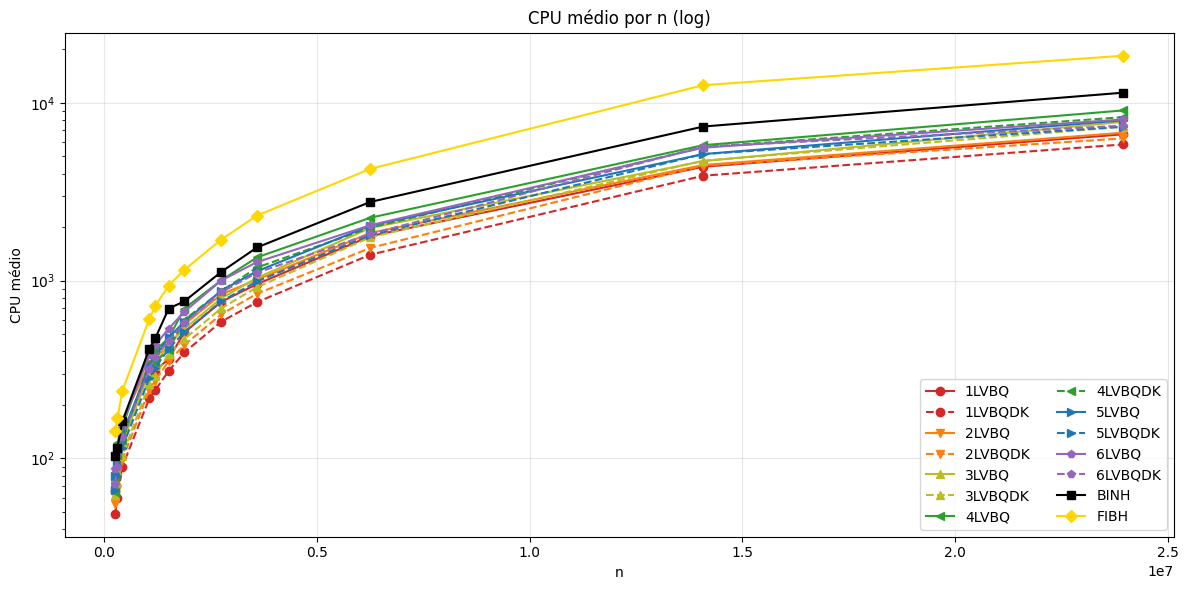

In [743]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (log)")
plt.yscale("log")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

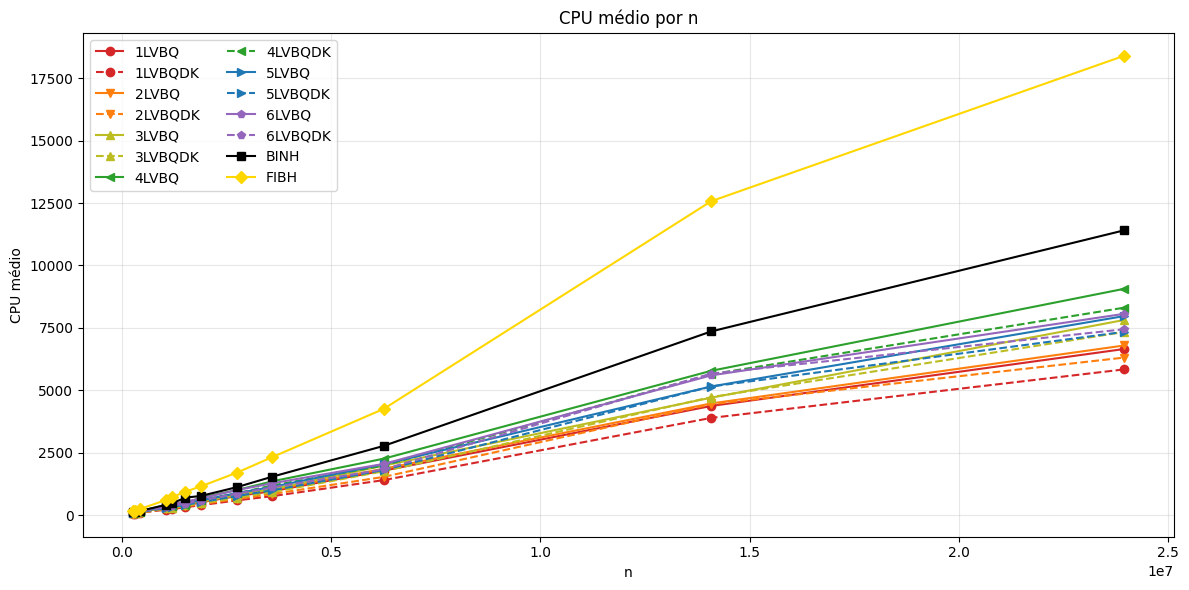

In [744]:

# selecionar BINH, Fibonacci e todas LVBQ (1–6) com ou sem DK
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ(DK)?"))
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ / LVBQDK =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        # DK → tracejado
        linestyle = "--" if "DK" in fila else "-"

        # marcador por nível
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

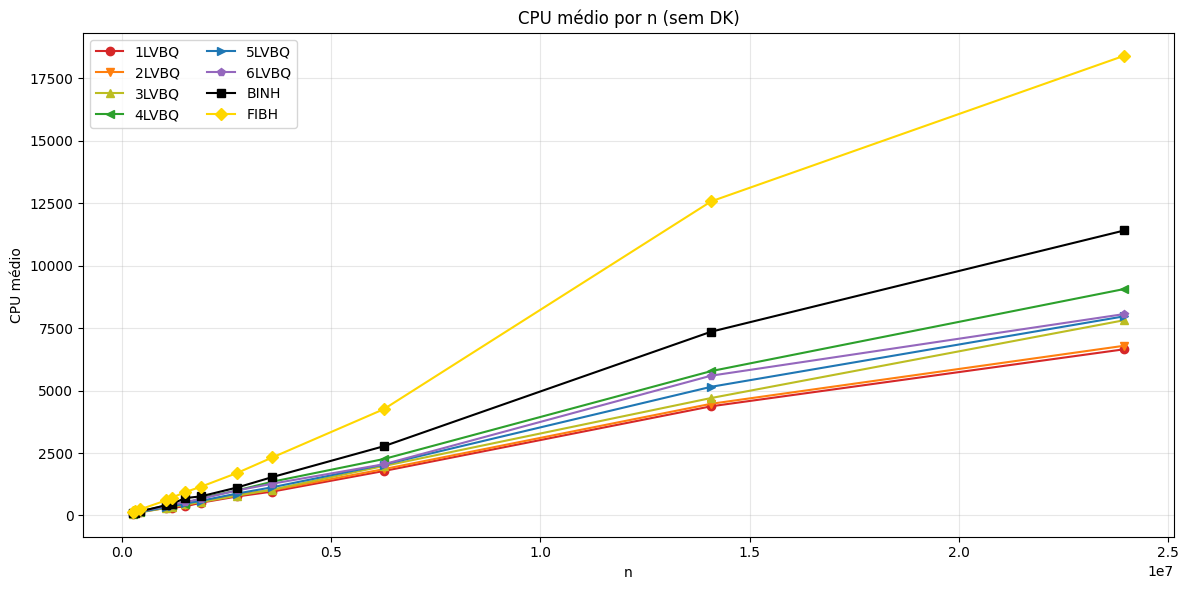

In [745]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **sem DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQ$"))  # somente LVBQ sem DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ simples (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "-"  # todas LVBQ simples são sólidas
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio")
plt.title("CPU médio por n (sem DK)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

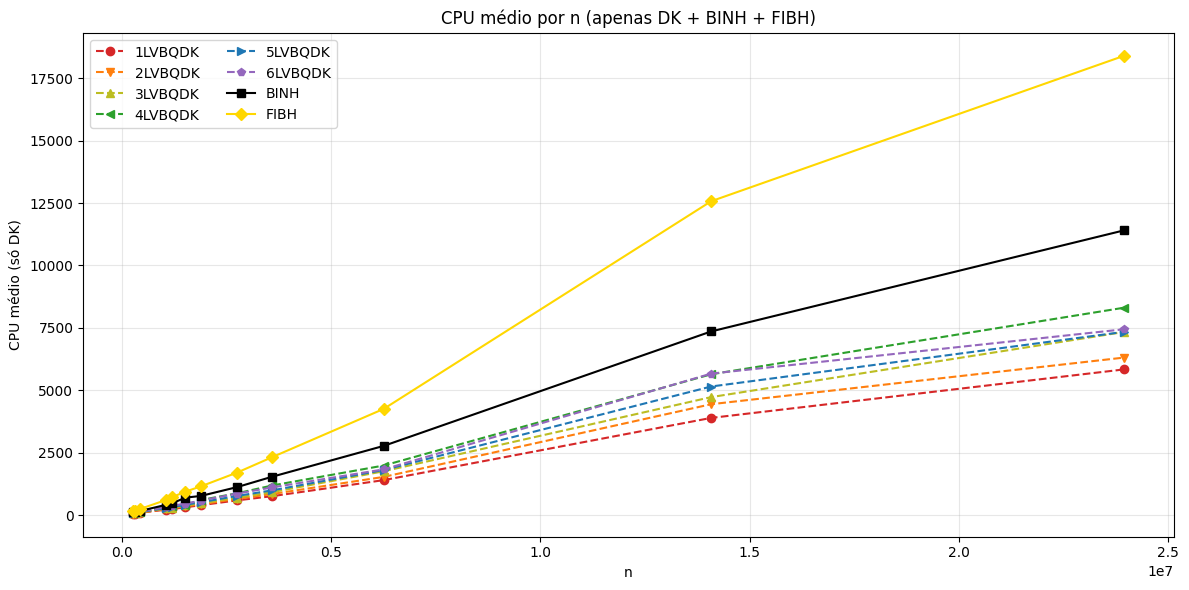

In [746]:
# 🎯 selecionar BINH, Fibonacci e todas LVBQ (1–6) **apenas DK**
mask = (
    (df_cpu["fila"] == "BINH") |
    (df_cpu["fila"] == "FIBH") |  # adiciona Fibonacci
    (df_cpu["fila"].str.match(r"[1-6]LVBQDK$"))  # somente LVBQ DK
)

df_sel = df_cpu[mask].copy()

# ordenar por n (ESSENCIAL para gráfico de linhas)
df_sel = df_sel.sort_values("n")

# ordem consistente das curvas
filas_sel = sorted(df_sel["fila"].unique())

# 🔹 marcadores por nível LVBQ
marcadores_nivel = {
    1: "o",   # círculo
    2: "v",   # triângulo para baixo
    3: "^",   # triângulo para cima
    4: "<",   # triângulo para esquerda
    5: ">",   # triângulo para direita
    6: "p",   # pentágono
}

plt.figure(figsize=(12, 6))

for fila in filas_sel:
    dados = df_sel[df_sel["fila"] == fila]

    if dados.empty:
        continue

    # ===== BINH =====
    if fila == "BINH":
        color = "black"
        linestyle = "-"
        marker = "s"

    # ===== FIBH (Fibonacci) =====
    elif fila == "FIBH":
        color = "gold"
        linestyle = "-"
        marker = "D"  # diamante

    # ===== LVBQ DK (1–6) =====
    else:
        nivel = int(re.match(r"\d+", fila).group())

        # 🎨 cor por nível (1–6)
        cores = {
            1: "tab:red",
            2: "tab:orange",
            3: "tab:olive",
            4: "tab:green",
            5: "tab:blue",
            6: "tab:purple",
        }
        color = cores[nivel]

        linestyle = "--"  # DK → tracejado
        marker = marcadores_nivel[nivel]

    plt.plot(
        dados["n"],
        dados["cpu_mean"],
        label=fila,
        color=color,
        linestyle=linestyle,
        marker=marker
    )

plt.xlabel("n")
plt.ylabel("CPU médio (só DK)")
plt.title("CPU médio por n (apenas DK + BINH + FIBH)")
plt.legend(ncol=2)  # legenda mais compacta
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Outras métricas

In [747]:
df_tcache.head(10)

,nome,n,m,c,insert,extractMin,dk,bkmp,fila,cpu_time,...,page_faults,branch_inst,branch_miss,extra_extractMin,l1_rate,llc_rate,ipc,dtlb_rate,pf_rate,bm_rate
0,NY,264346,733846,36946,298760,298760,0,875156,1LVBQ,68,...,76,74111933,759040,34414,0.015196,0.426935,2.362443,0.000034,1.846079e-07,0.010242
1,NY,264346,733846,36946,298765,298765,0,793429,1LVBQ,67,...,0,73090719,747622,34419,0.014844,0.431963,2.409469,0.000035,0.000000e+00,0.010229
2,NY,264346,733846,36946,299090,299090,0,1266493,1LVBQ,66,...,0,72293451,729795,34744,0.014813,0.379963,2.505501,0.000027,0.000000e+00,0.010095
3,NY,264346,733846,36946,299174,299174,0,777084,1LVBQ,66,...,0,72063345,738137,34828,0.014799,0.411093,2.461998,0.000033,0.000000e+00,0.010243
4,NY,264346,733846,36946,299348,299348,0,905321,1LVBQ,66,...,0,71892564,739982,35002,0.014887,0.420099,2.448408,0.000032,0.000000e+00,0.010293
5,NY,264346,733846,36946,299542,299542,0,972486,1LVBQ,65,...,0,72387995,736389,35196,0.014913,0.401783,2.496830,0.000028,0.000000e+00,0.010173
6,NY,264346,733846,36946,299355,299355,0,889497,1LVBQ,66,...,0,73062016,750709,35009,0.014971,0.436578,2.432331,0.000032,0.000000e+00,0.010275
7,NY,264346,733846,36946,298494,298494,0,813050,1LVBQ,65,...,0,72904025,737836,34148,0.014814,0.383929,2.490124,0.000031,0.000000e+00,0.010121
8,NY,264346,733846,36946,299262,299262,0,824951,1LVBQ,65,...,0,72096213,736962,34916,0.014828,0.404016,2.478034,0.000033,0.000000e+00,0.010222
9,NY,264346,733846,36946,299542,299542,0,1098054,1LVBQ,66,...,0,73002420,736806,35196,0.014938,0.408299,2.491545,0.000028,0.000000e+00,0.010093


## Instruções

### Absolutas

In [748]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
      )
)

df_instc

,nome,fila,inst_mean
0,BAY,1LVBQ,5.147081e+08
1,BAY,1LVBQDK,3.502647e+08
2,BAY,2LVBQ,6.730888e+08
3,BAY,2LVBQDK,4.013055e+08
4,BAY,3LVBQ,5.943878e+08
...,...,...,...
163,W,5LVBQDK,9.554427e+09
164,W,6LVBQ,1.271149e+10
165,W,6LVBQDK,9.702002e+09
166,W,BINH,1.623354e+10


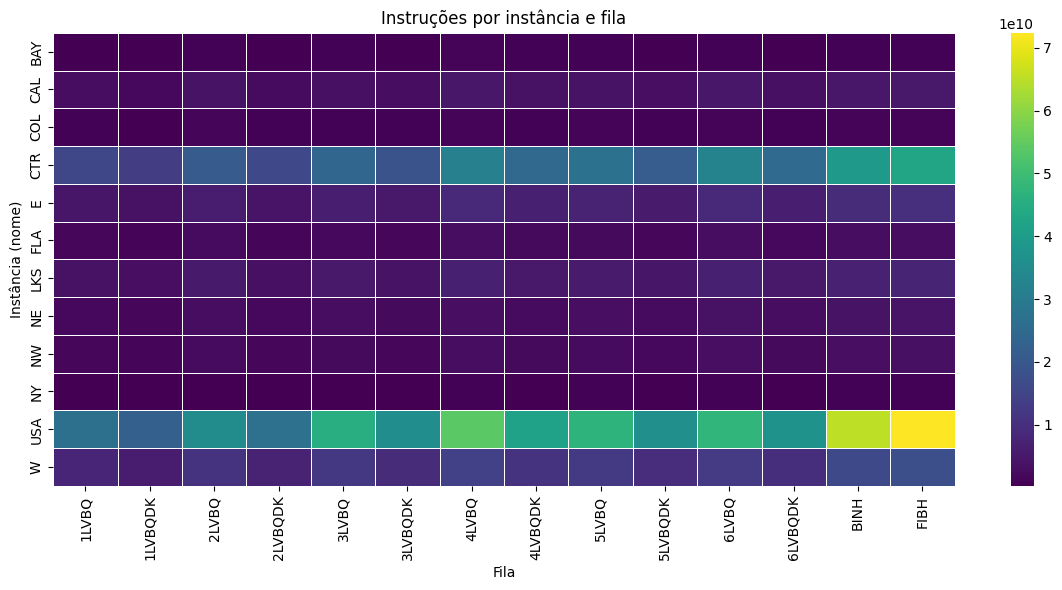

In [749]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Instruções por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

### IPC (Inst/Cycle, quanto maior, melhor)

In [750]:
df_instc = df_tcache[
    ['nome', 'fila', 'inst', 'cycles']
].copy()

df_instc = (
    df_instc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_total=('inst', 'sum'),
           cycles_total=('cycles', 'sum'),
      )
)

df_instc['ipc'] = (
    df_instc['inst_total'] /
    df_instc['cycles_total'].replace(0, np.nan)
)

df_instc

,nome,fila,inst_total,cycles_total,ipc
0,BAY,1LVBQ,5147080504,2040482909,2.522482
1,BAY,1LVBQDK,3502646962,1489428650,2.351672
2,BAY,2LVBQ,6730887895,2197448173,3.063047
3,BAY,2LVBQDK,4013054751,1669030462,2.404423
4,BAY,3LVBQ,5943878206,2050659286,2.898521
...,...,...,...,...,...
163,W,5LVBQDK,95544272713,40782360060,2.342784
164,W,6LVBQ,127114894512,45342196799,2.803457
165,W,6LVBQDK,97020018561,41298113209,2.349260
166,W,BINH,162335398945,61528344390,2.638384


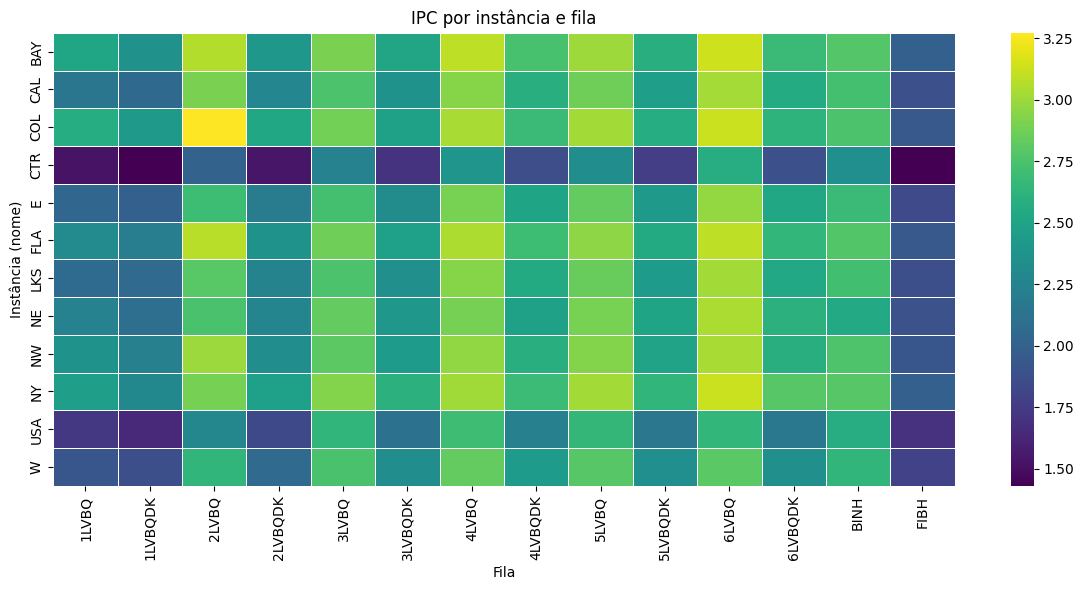

In [751]:

# ===== métrica escolhida =====
df_plot = df_instc.copy()

# opção A: LLC apenas
df_plot["miss"] = df_plot["ipc"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="ipc")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

## Branch Miss Rate

In [752]:
df_branches = df_tcache[
    ['nome', 'fila', 'branch_miss', 'branch_inst']
].copy()
df_branches['bm_rate'] = df_branches['branch_miss'] / df_branches['branch_inst']

# agregar
df_branches = (
    df_branches.groupby(['nome', 'fila'], as_index=False)
      .agg(
           bm_mean=('bm_rate', 'mean'),
           bm_std =('bm_rate', 'std'),
           bm_var =('bm_rate', 'var'),
      )
)
df_branches['bm_cv'] = df_branches['bm_std'] / df_branches['bm_mean']
df_branches

,nome,fila,bm_mean,bm_std,bm_var,bm_cv
0,BAY,1LVBQ,0.009307,0.000201,4.040804e-08,0.021598
1,BAY,1LVBQDK,0.014445,0.000393,1.541442e-07,0.027180
2,BAY,2LVBQ,0.005631,0.000160,2.563424e-08,0.028434
3,BAY,2LVBQDK,0.013668,0.000113,1.286079e-08,0.008297
4,BAY,3LVBQ,0.007059,0.000217,4.690166e-08,0.030678
...,...,...,...,...,...,...
163,W,5LVBQDK,0.013074,0.000449,2.017869e-07,0.034360
164,W,6LVBQ,0.006000,0.000109,1.195564e-08,0.018225
165,W,6LVBQDK,0.012708,0.000522,2.725003e-07,0.041077
166,W,BINH,0.013804,0.000083,6.825353e-09,0.005985


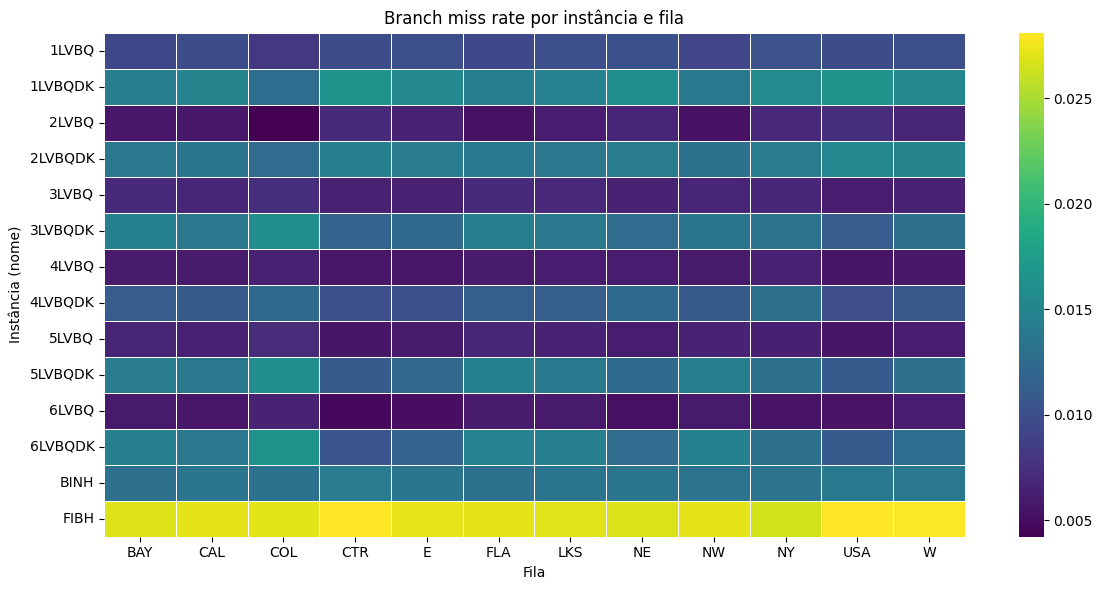

In [753]:

# ===== métrica escolhida =====
df_plot = df_branches.copy()

df_plot["miss"] = df_plot["bm_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="fila", columns="nome", values="bm_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Branch miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

## Instruções em CPU

In [754]:
df_inst = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst']
].copy()
df_inst = (
    df_inst.groupby(['nome', 'fila'], as_index=False)
      .agg(
           inst_mean=('inst', 'mean'),
           inst_std =('inst', 'std'),
           inst_var =('inst', 'var'),
           n=('n', 'first'),
      )
)
df_inst['inst_cv'] = df_inst['inst_std'] / df_inst['inst_mean']
df_inst

,nome,fila,inst_mean,inst_std,inst_var,n,inst_cv
0,BAY,1LVBQ,5.147081e+08,1.136972e+07,1.292704e+14,321270,0.022090
1,BAY,1LVBQDK,3.502647e+08,6.958586e+06,4.842191e+13,321270,0.019867
2,BAY,2LVBQ,6.730888e+08,2.658931e+07,7.069915e+14,321270,0.039503
3,BAY,2LVBQDK,4.013055e+08,4.130279e+06,1.705921e+13,321270,0.010292
4,BAY,3LVBQ,5.943878e+08,3.247514e+06,1.054635e+13,321270,0.005464
...,...,...,...,...,...,...,...
163,W,5LVBQDK,9.554427e+09,1.121770e+07,1.258368e+14,6262104,0.001174
164,W,6LVBQ,1.271149e+10,5.301790e+07,2.810897e+15,6262104,0.004171
165,W,6LVBQDK,9.702002e+09,1.211283e+07,1.467205e+14,6262104,0.001248
166,W,BINH,1.623354e+10,3.681837e+08,1.355592e+17,6262104,0.022680


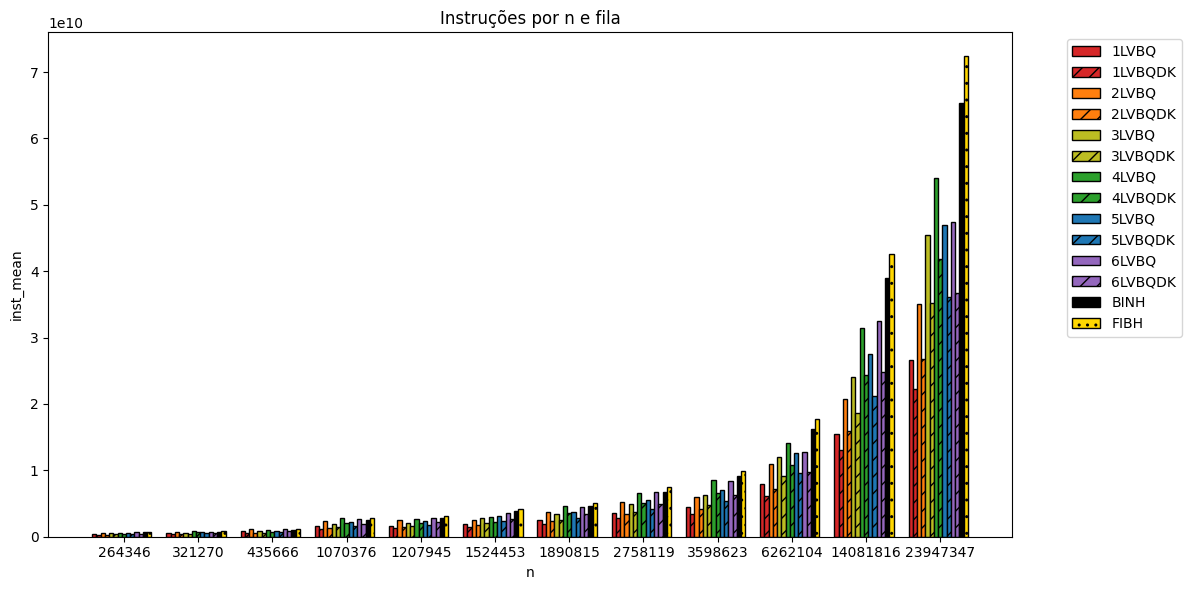

In [755]:
pivot = df_inst.pivot_table(
    index="n",
    columns="fila",
    values="inst_mean", 
)

n_vals = pivot.index.to_list()
filas = pivot.columns.to_list()

x = np.arange(len(n_vals))
width = 0.8 / len(filas)

# 🎨 cores por número da fila (LVBQ)
colors = {
    "1": "tab:red",
    "2": "tab:orange",
    "3": "tab:olive",
    "4": "tab:green",
    "5": "tab:blue",
    "6": "tab:purple",
}

plt.figure(figsize=(12, 6))

for i, fila in enumerate(filas):

    # ===== HEAPS (se existirem) =====
    if "BINH" in fila:
        color = "black"
        hatch = "xx"
        
    elif "FIBH" in fila:
        color = "gold"
        hatch = ".."

    # ===== LVBQ / LVBQDK =====
    else:
        m = re.match(r"\d+", fila)
        num = m.group() if m else None

        color = colors.get(num, "tab:gray")

        # DK com padrão
        hatch = "//" if "LVBQDK" in fila else None

    plt.bar(
        x + i * width,
        pivot[fila].values,
        width,
        label=fila,
        color=color,
        hatch=hatch,
        edgecolor="black"
    )

plt.xticks(x + width * len(filas) / 2, n_vals)
plt.xlabel("n")
plt.ylabel("inst_mean")
plt.title("Instruções por n e fila")
plt.legend(bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

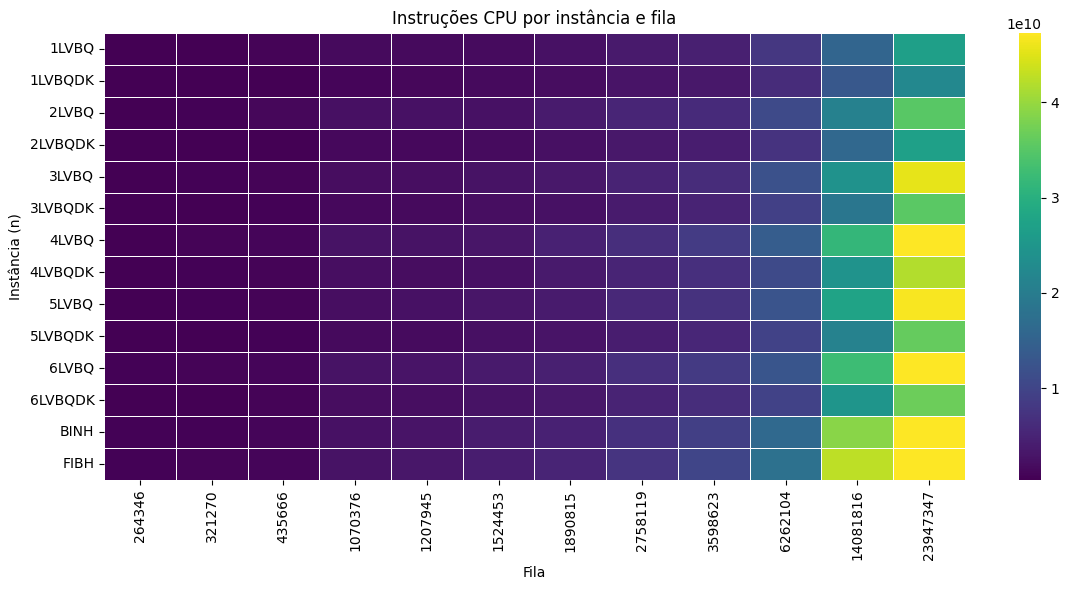

In [756]:

# ===== métrica escolhida =====
df_plot = df_inst.copy()

df_plot["inst"] = df_plot["inst_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="fila", columns="n", values="inst_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    robust=True
)

plt.title("Instruções CPU por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (n)")

plt.tight_layout()
plt.show()

### IPC

In [757]:
df_ipc = df_tcache[
    ['nome', 'n', 'c', 'fila', 'inst', 'cycles']
].copy()

df_ipc['ipc'] = df_ipc['inst']/df_ipc['cycles']

df_ipc = (
    df_ipc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           ipc_mean=('ipc', 'mean'),
           ipc_std =('ipc', 'std'),
           ipc_var =('ipc', 'var'),
           n=('n', 'first'),
      )
)
df_ipc['ipc_cv'] = df_ipc['ipc_std'] / df_ipc['ipc_mean']
df_ipc

,nome,fila,ipc_mean,ipc_std,ipc_var,n,ipc_cv
0,BAY,1LVBQ,2.522925,0.055793,0.003113,321270,0.022114
1,BAY,1LVBQDK,2.351749,0.050472,0.002547,321270,0.021461
2,BAY,2LVBQ,3.062297,0.037213,0.001385,321270,0.012152
3,BAY,2LVBQDK,2.404519,0.026034,0.000678,321270,0.010827
4,BAY,3LVBQ,2.898740,0.026487,0.000702,321270,0.009137
...,...,...,...,...,...,...,...
163,W,5LVBQDK,2.343815,0.053177,0.002828,6262104,0.022688
164,W,6LVBQ,2.804095,0.049933,0.002493,6262104,0.017807
165,W,6LVBQDK,2.351240,0.071933,0.005174,6262104,0.030594
166,W,BINH,2.639417,0.034573,0.001195,6262104,0.013099


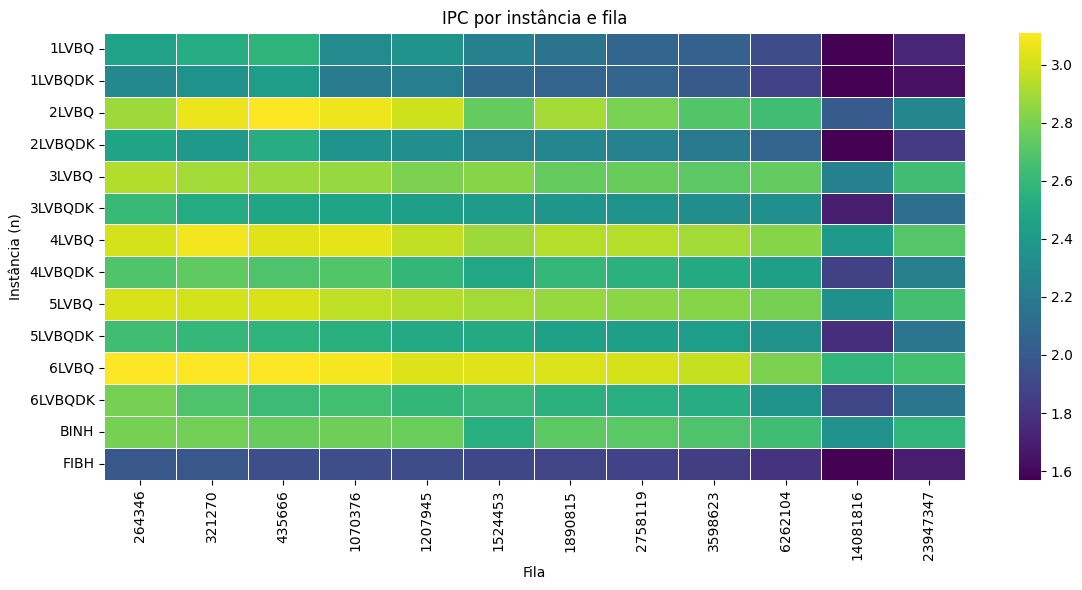

In [758]:

# ===== métrica escolhida =====
df_plot = df_ipc.copy()

df_plot["inst"] = df_plot["ipc_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="fila", columns="n", values="ipc_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white",
    robust=True
)

plt.title("IPC por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (n)")

plt.tight_layout()
plt.show()

## Cache miss Rate

In [759]:
# Miss Rate (misses/chamadas)
df_l1 = df_tcache[
    ['nome', 'fila', 'l1_miss', 'l1_ac']
].copy()
ac_safe = df_l1["l1_ac"].replace(0, np.nan)
df_l1['l1_miss_rate'] = df_l1['l1_miss'] / ac_safe

# Agregar
df_l1 = (
    df_l1.groupby(['nome', 'fila'], as_index=False)
      .agg(
           l1_mr_mean=('l1_miss_rate', 'mean'),
           l1_mr_std =('l1_miss_rate', 'std'),
           l1_mr_var =('l1_miss_rate', 'var'),
      )
)
df_l1['l1_mr_cv'] = df_l1['l1_mr_std'] / df_l1['l1_mr_mean']
df_l1

,nome,fila,l1_mr_mean,l1_mr_std,l1_mr_var,l1_mr_cv
0,BAY,1LVBQ,0.014380,0.000149,2.226514e-08,0.010377
1,BAY,1LVBQDK,0.016428,0.000988,9.754251e-07,0.060120
2,BAY,2LVBQ,0.007713,0.000537,2.886542e-07,0.069657
3,BAY,2LVBQDK,0.012284,0.000862,7.425137e-07,0.070145
4,BAY,3LVBQ,0.006055,0.000329,1.083506e-07,0.054358
...,...,...,...,...,...,...
163,W,5LVBQDK,0.016393,0.001030,1.060774e-06,0.062827
164,W,6LVBQ,0.007712,0.000323,1.042943e-07,0.041878
165,W,6LVBQDK,0.016374,0.001169,1.365802e-06,0.071372
166,W,BINH,0.006369,0.000623,3.880023e-07,0.097802


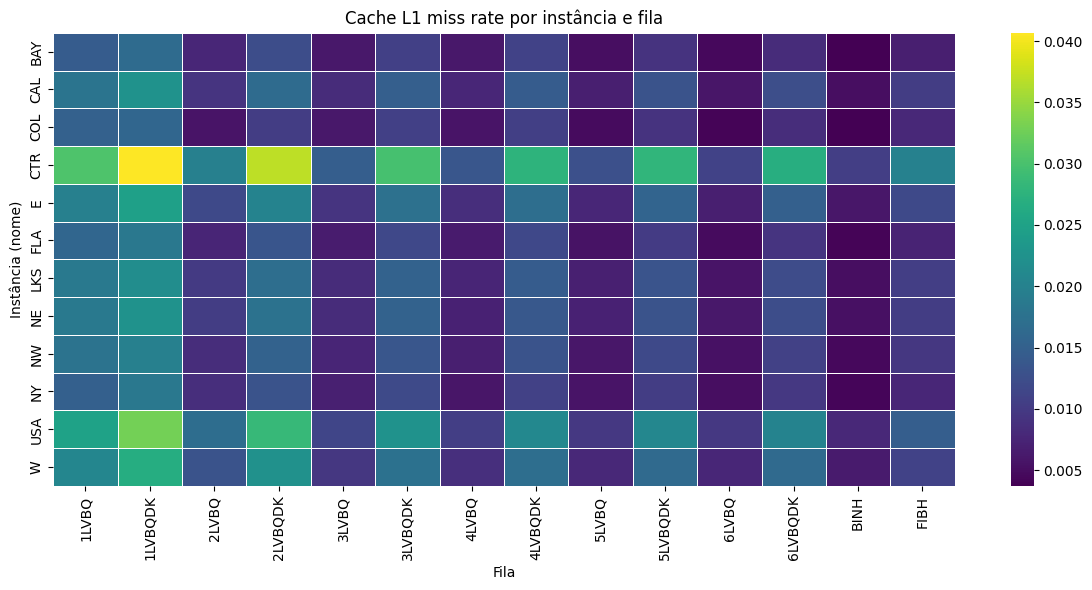

In [760]:

# ===== métrica escolhida =====
df_plot = df_l1.copy()

df_plot["miss"] = df_plot["l1_mr_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="l1_mr_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("Cache L1 miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()

In [761]:
# Miss Rate (misses/chamadas)
df_llc = df_tcache[
    ['nome', 'fila', 'llc_miss', 'llc_ac']
].copy()
ac_safe = df_llc["llc_ac"].replace(0, np.nan)
df_llc['llc_miss_rate'] = df_llc['llc_miss'] / ac_safe

# Agregar
df_llc = (
    df_llc.groupby(['nome', 'fila'], as_index=False)
      .agg(
           llc_mr_mean=('llc_miss_rate', 'mean'),
           llc_mr_std =('llc_miss_rate', 'std'),
           llc_mr_var =('llc_miss_rate', 'var'),
      )
)
df_llc['llc_mr_cv'] = df_llc['llc_mr_std'] / df_llc['llc_mr_mean']
df_llc

,nome,fila,llc_mr_mean,llc_mr_std,llc_mr_var,llc_mr_cv
0,BAY,1LVBQ,0.394583,0.025129,0.000631,0.063686
1,BAY,1LVBQDK,0.450982,0.019742,0.000390,0.043775
2,BAY,2LVBQ,0.490269,0.026985,0.000728,0.055041
3,BAY,2LVBQDK,0.511370,0.015021,0.000226,0.029374
4,BAY,3LVBQ,0.466520,0.024278,0.000589,0.052040
...,...,...,...,...,...,...
163,W,5LVBQDK,0.348168,0.025633,0.000657,0.073623
164,W,6LVBQ,0.385255,0.015838,0.000251,0.041110
165,W,6LVBQDK,0.334218,0.020226,0.000409,0.060517
166,W,BINH,0.400764,0.032859,0.001080,0.081992


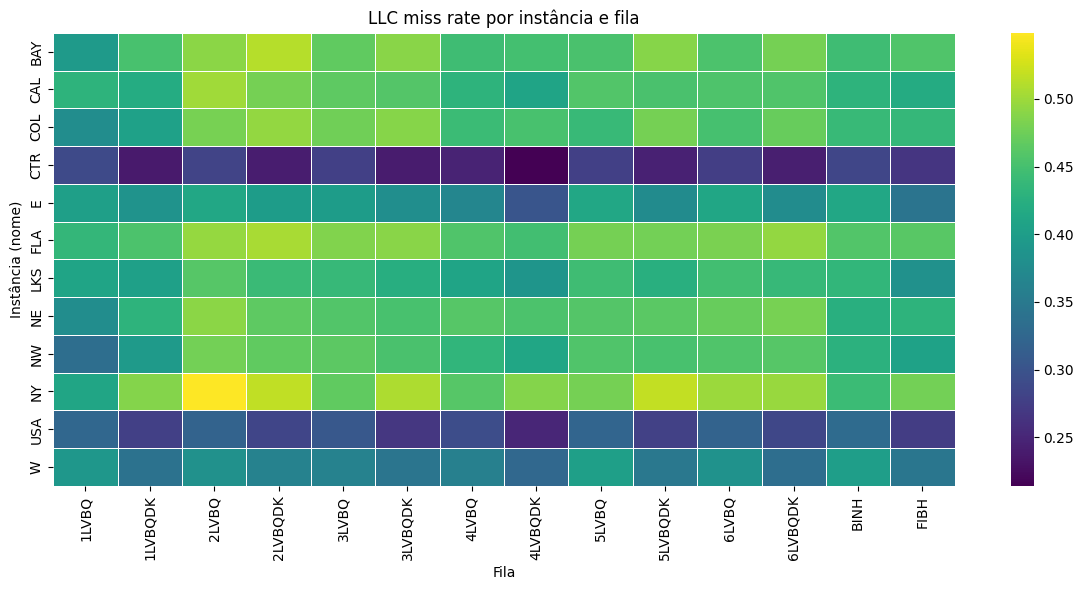

In [762]:

# ===== métrica escolhida =====
df_plot = df_llc.copy()

df_plot["miss"] = df_plot["llc_mr_mean"]

# ===== pivot =====
heat = df_plot.pivot(index="nome", columns="fila", values="llc_mr_mean")

# ===== plot =====
plt.figure(figsize=(12, 6))

sns.heatmap(
    heat,
    cmap="viridis",
    linewidths=0.5,
    linecolor="white"
)

plt.title("LLC miss rate por instância e fila")
plt.xlabel("Fila")
plt.ylabel("Instância (nome)")

plt.tight_layout()
plt.show()